In this notebook, we will compute the ecDNA copy number, and see how does copy number relates to other molecular features

In [1]:
import os
import numpy as np
import pandas as pd

In [2]:
sys.path.append('../scripts/')
from ecDNA_cts_helper import *
from plot import *

In [83]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 18,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "svg.fonttype": "none",   # keep text as editable text
})


# compute copy number

In the in vitro experiment, copy number was computed by taking the average number of spots over a set number of rounds: The first two loci exhibited higher detection efficiency and reduced cumulative signal loss compared to later imaging rounds. In addition to the first two loci, we computed the mean number of spots across the promoters of EGFR and EGFR-AS1 (four additional loci total), which would normally be targeted with standard EGFR DNA FISH. We took the average number of foci across the six loci per cell, and used that for copy number analysis.

## setup

In [3]:
fovs = [f'Conv_zscan1__{str(ifov).zfill(3)}' for ifov in range(20,51)]
len(fovs)

31

## identify foci

In [4]:
## segmentation files
dic_segm_fls = get_dic_segm(segm_fld = r'Y:\dragonfruit1\CellCulture_EGFR_03_01_2025__merged_Segmentation')

In [5]:
## drift files
drift_fls = glob.glob(r'D:\GBM39\invitro_030125\CellCulture_EGFR_03_01_2025__DNA_cts_select_regions\drift*')

In [7]:
## drift files
H1_drift_fls = glob.glob(r'Y:\dragonfruit2\CellCulture_EGFR_03_01_2025__H1_DNA_analysis\H1*')

In [11]:
DNA_tags = ['H1_P1F123',
           'D17_P2A101112',
           'D27_P2D456']

In [12]:
dic_ths = {
    'H1_P1F123': [np.exp(10.5),np.exp(11)],
'D17_P2A101112':[np.exp(10.5),np.exp(10)],
 'D27_P2D456': [np.exp(9.5),np.exp(10)]}

In [131]:
suffix = ''
save_fld = r'D:\GBM39\invitro_030125\CellCulture_EGFR_03_01_2025__copy_number_6_regions'
analysis_fld = r'D:\GBM39\invitro_030125\CellCulture_EGFR_03_01_2025__DNA_cts_select_regions'
H1_analysis_fld = r'Y:\dragonfruit2\CellCulture_EGFR_03_01_2025__H1_DNA_analysis'
os.makedirs(save_fld, exist_ok=True)

for fov in tqdm(fovs):
    ## add H1 to drift folder
    ## get the drift for this fov per round
    dic_drifts = get_dic_drifts(fov, drift_fls = drift_fls) 
    dic_H1_drifts = get_dic_drifts(fov, drift_fls = H1_drift_fls)

    dic_drifts['H1_P1F123'] = dic_H1_drifts['H1_P1F123']

    set_ = 'set' + fov.split('__')[0].split('zscan')[-1]
    
    save_fls = []
    for htag in DNA_tags:
        if htag == 'H1_P1F123':
            input_fld = H1_analysis_fld
        else:
            input_fld = analysis_fld

        
        for icol in [0,1]:
            save_fl = os.path.join(f'{save_fld}{suffix}', f'{fov}--{htag}--col{icol}--X_cts{suffix}.npz')
            
            counts_matrix, header,Xtmp = get_XH_DNA_single(fov, htag,set_,
                        icol = icol,
                   dic_drifts = dic_drifts,
                   dic_segm_fls = dic_segm_fls,  
                   th_h = dic_ths[htag][icol],
                   chrom_mat = [0,0,0],                                                     
                  analysis_fld = input_fld,
                    save_fld = save_fld,
                  force = False,
                       suffix = '')
            save_fls.append(save_fl)
    cts_fov = assemble_counts_fov_redo(fov, save_fld = save_fld, 
                                      tags = DNA_tags,
                                 save_fls = save_fls, force = True, suffix = suffix)

In [42]:
## format the matrix
## put together all sets
type_tag = 'DNA'
experiment_tag = 'invitro_030125'
suffix = ''

cts_fov_fls = glob.glob(os.path.join(save_fld, f'Conv_zscan*--{type_tag}_X_cts_fov{suffix}.csv'))
master_df = pd.concat([pd.read_csv(fl) for fl in cts_fov_fls])
save_fl = os.path.join(save_fld,f'{type_tag}_cts_mat--{experiment_tag}{suffix}.csv')
print(save_fl)


D:\GBM39\invitro_030125\CellCulture_EGFR_03_01_2025__copy_number_6_regions\DNA_cts_mat--invitro_030125.csv


In [43]:
## remove potential speckles
df_nospeckle = master_df.copy()# Identify rows where any _speckle column has a value > 0
mask = (df_nospeckle.filter(regex='_speckle$') > 0).any(axis=1)

# Identify columns that contain 'counts'
count_cols = df_nospeckle.filter(like='counts').columns

# Set only the 'counts' columns to NaN for the matching rows
df_nospeckle.loc[mask, count_cols] = np.nan

In [44]:
nuc_count_cols = [col for col in count_cols if '_nuc' in col]
nuc_count_cols

['H1_P1F123_col0-counts_nuc',
 'H1_P1F123_col1-counts_nuc',
 'D17_P2A101112_col0-counts_nuc',
 'D17_P2A101112_col1-counts_nuc',
 'D27_P2D456_col0-counts_nuc',
 'D27_P2D456_col1-counts_nuc']

In [45]:
## select the nuclear version of all 6 regions
df_copy_number = df_nospeckle[['fov_ifovcell', 'ifovcell'] + nuc_count_cols]

In [46]:
df_copy_number['ecDNA_mean_6_regions'] = df_copy_number[nuc_count_cols].mean(axis = 1)

C:\Users\RenLabUser\AppData\Local\Temp\ipykernel_67248\3841936704.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_number['ecDNA_mean_6_regions'] = df_copy_number[nuc_count_cols].mean(axis = 1)


In [53]:
## merge it with the previous quantifications
df_ecDNA_input = pd.read_csv(r'C:/GBM39/invirto_030125/022026_antibody_entirecell_global_brightness_copygroup_ecDNA_iset1__invitro_030125.csv', index_col = 0)

# stratify by copy number

Assign low/high copy number based on quantile

In [56]:
df_ecDNA_mean = pd.merge(df_ecDNA_input, df_copy_number[['fov_ifovcell', 'ecDNA_mean_6_regions']], on = 'fov_ifovcell', how = 'inner')

In [59]:
df_ecDNA_mean['log2_ecDNA_copynumber'] = np.log2(df_ecDNA_mean['ecDNA_mean_6_regions']+1)

## plot copy number distribution

In [60]:
qlo = df_ecDNA_mean['log2_ecDNA_copynumber'].quantile(0.25)
qhi = df_ecDNA_mean['log2_ecDNA_copynumber'].quantile(0.75)
print(f'log2 copy number cutoff: low = {qlo}, high = {qhi}')

df_ecDNA_mean["copy_group"] = np.where(df_ecDNA_mean['log2_ecDNA_copynumber'] <= qlo, "low",
                     np.where(df_ecDNA_mean['log2_ecDNA_copynumber'] >= qhi, "high", "mid"))

log2 copy number cutoff: low = 5.643856189774724, high = 6.855906666889713


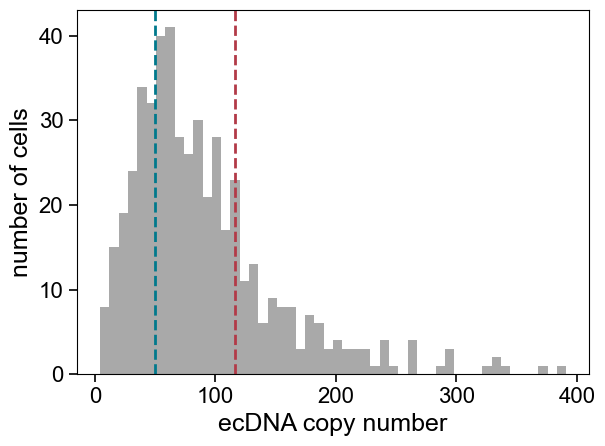

In [84]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.hist(df_ecDNA_mean['ecDNA_mean_6_regions'], bins=50, color = 'darkgray')
ax.axvline(x=2**qlo, color="#00798C", linestyle="--", lw=2)
ax.axvline(x=2**qhi, color="#B23A48", linestyle="--", lw=2)
ax.set_xlabel("ecDNA copy number")
ax.set_ylabel("number of cells")
ax.tick_params(
    axis="both",
    which="major",
    direction="out",     # outward ticks (journal style)
    bottom=True,
    top=False,
    left=True,
    right=False,
    length=6,            # tick length
    width=1.2,           # tick thickness
)
# ax.set_title("")

fig.tight_layout()

# fig.savefig(
#     "C:/GBM39/manuscript_figures/invitro_fig2/plots/cell_level_low_high_features/copy_number_distribution.svg",
#     format="svg",
#     transparent=True,
#     dpi=300
# )

plt.show()


# compare features by copy number groups

In [65]:
df_plot_violin = df_ecDNA_mean[df_ecDNA_mean['copy_group'].isin(['low', 'high'])]
df_plot_violin['is_low'] = df_plot_violin['copy_group'] == 'low'

C:\Users\RenLabUser\AppData\Local\Temp\ipykernel_67248\888809635.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot_violin['is_low'] = df_plot_violin['copy_group'] == 'low'


In [132]:
fig, axes = plt.subplots(3, 2, figsize=(10, 8), dpi=200, sharex=True)

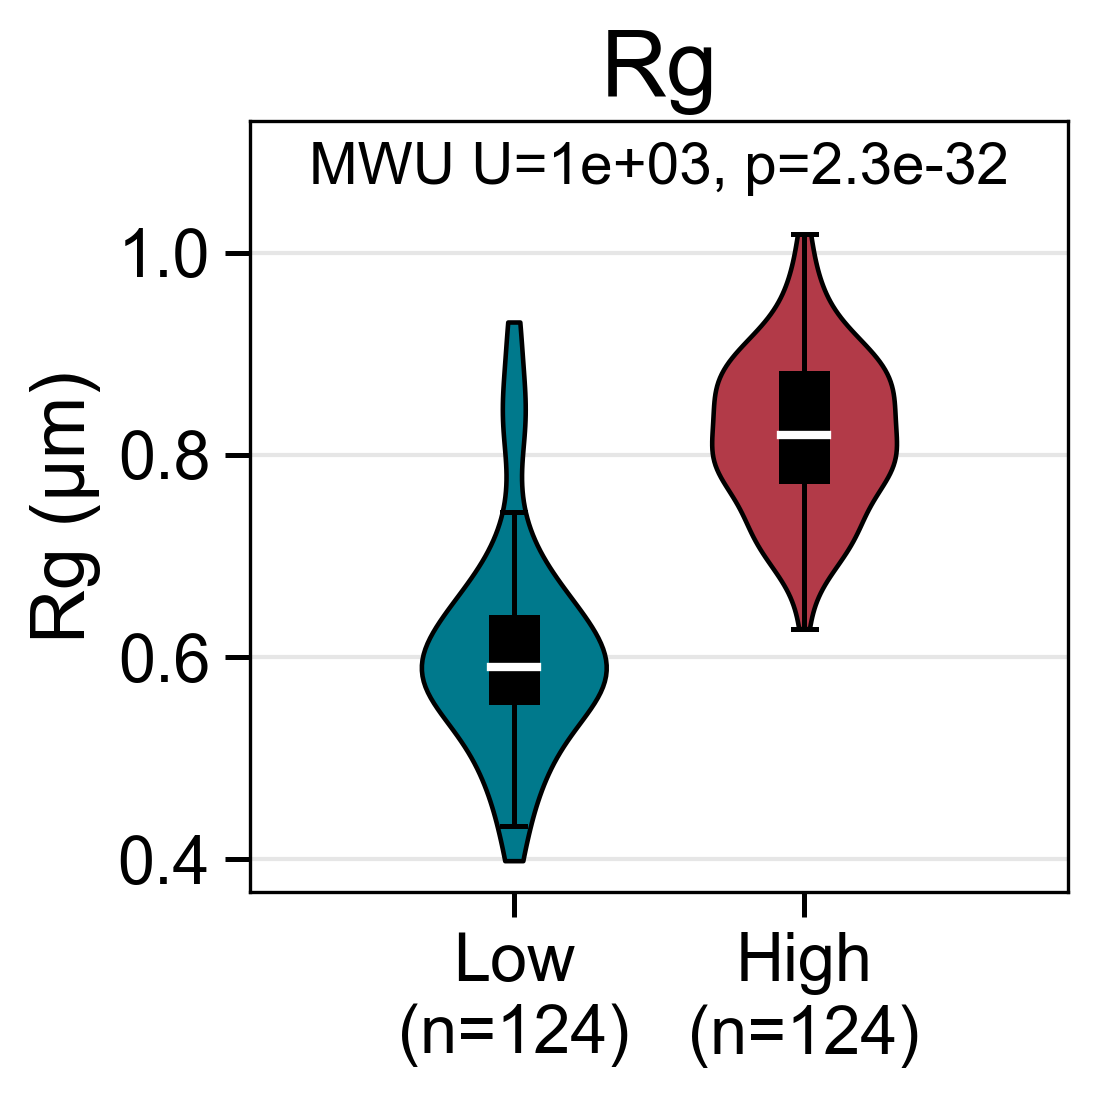

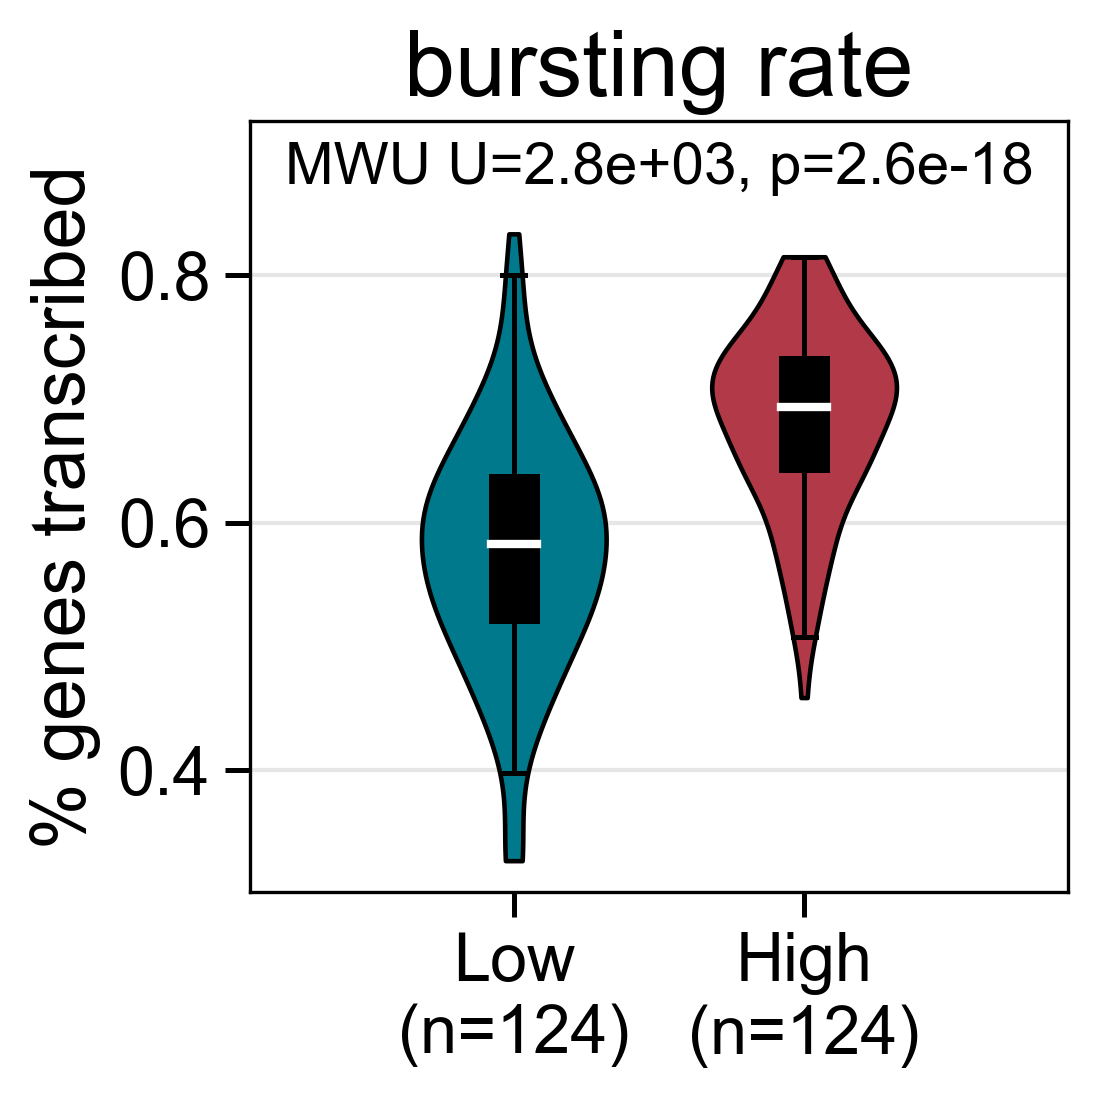

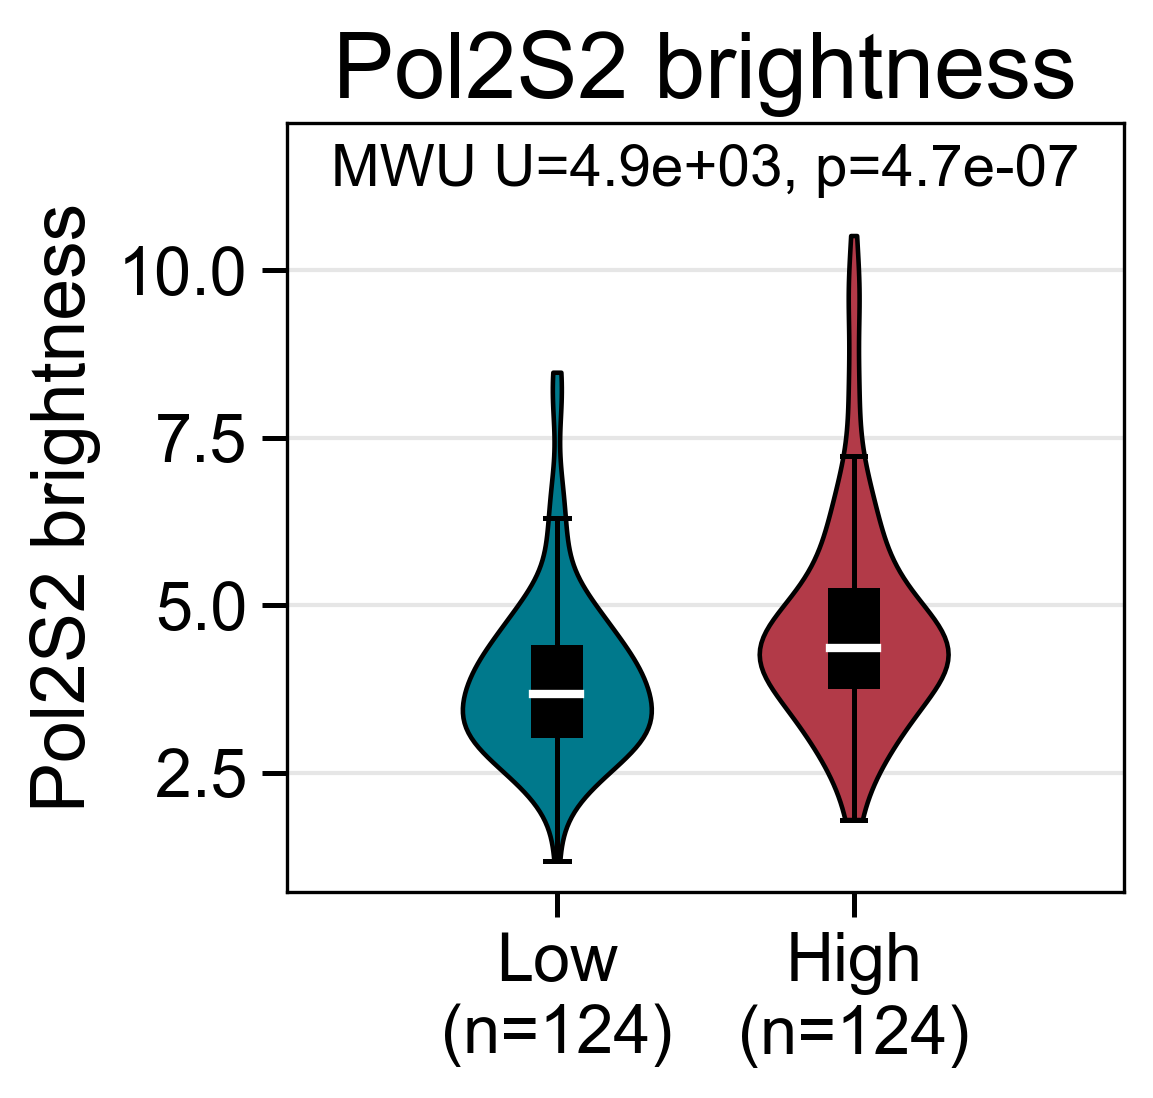

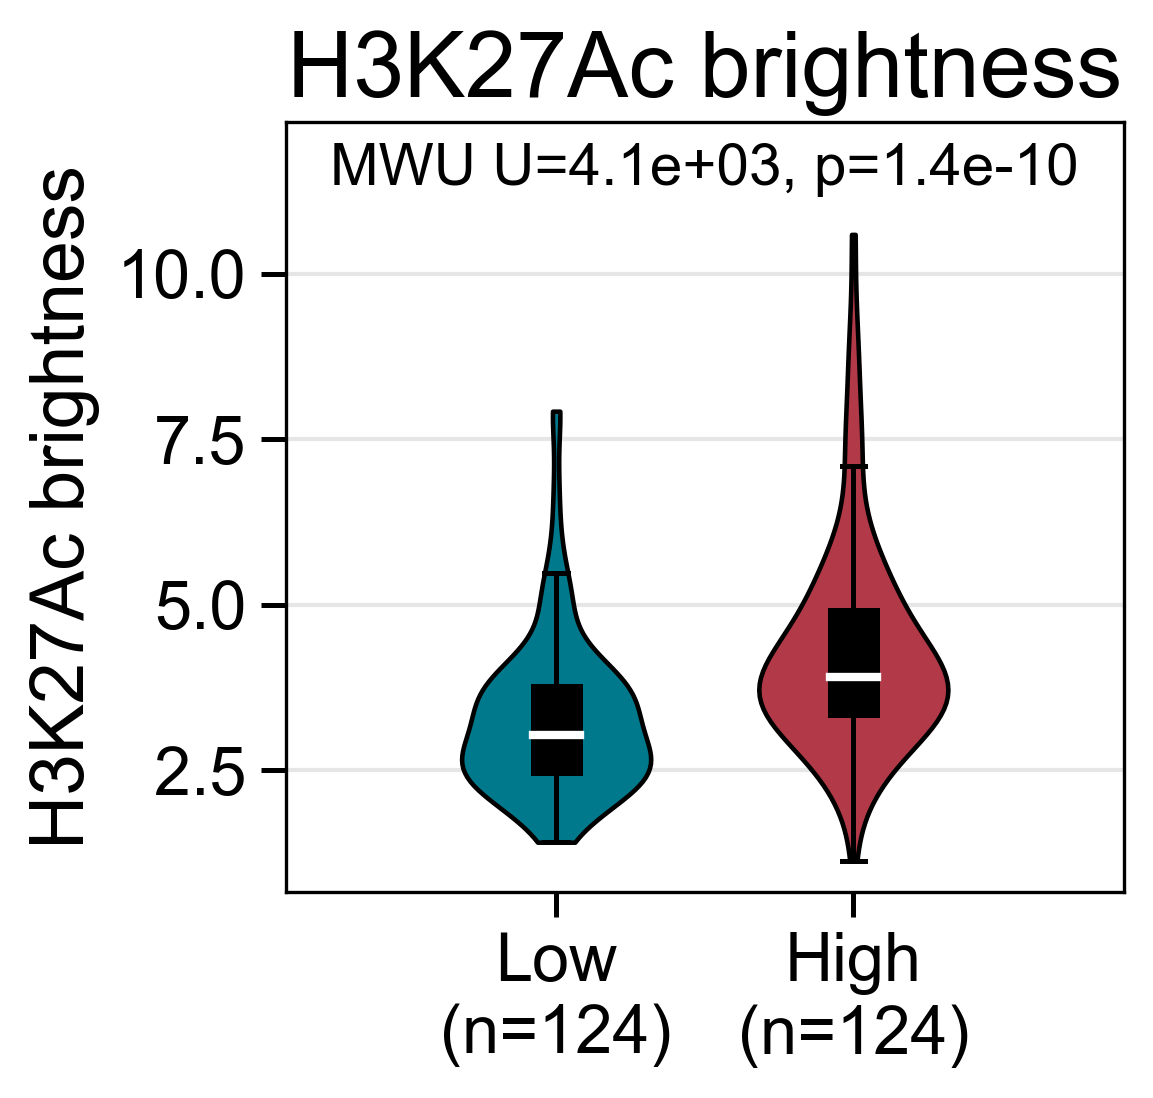

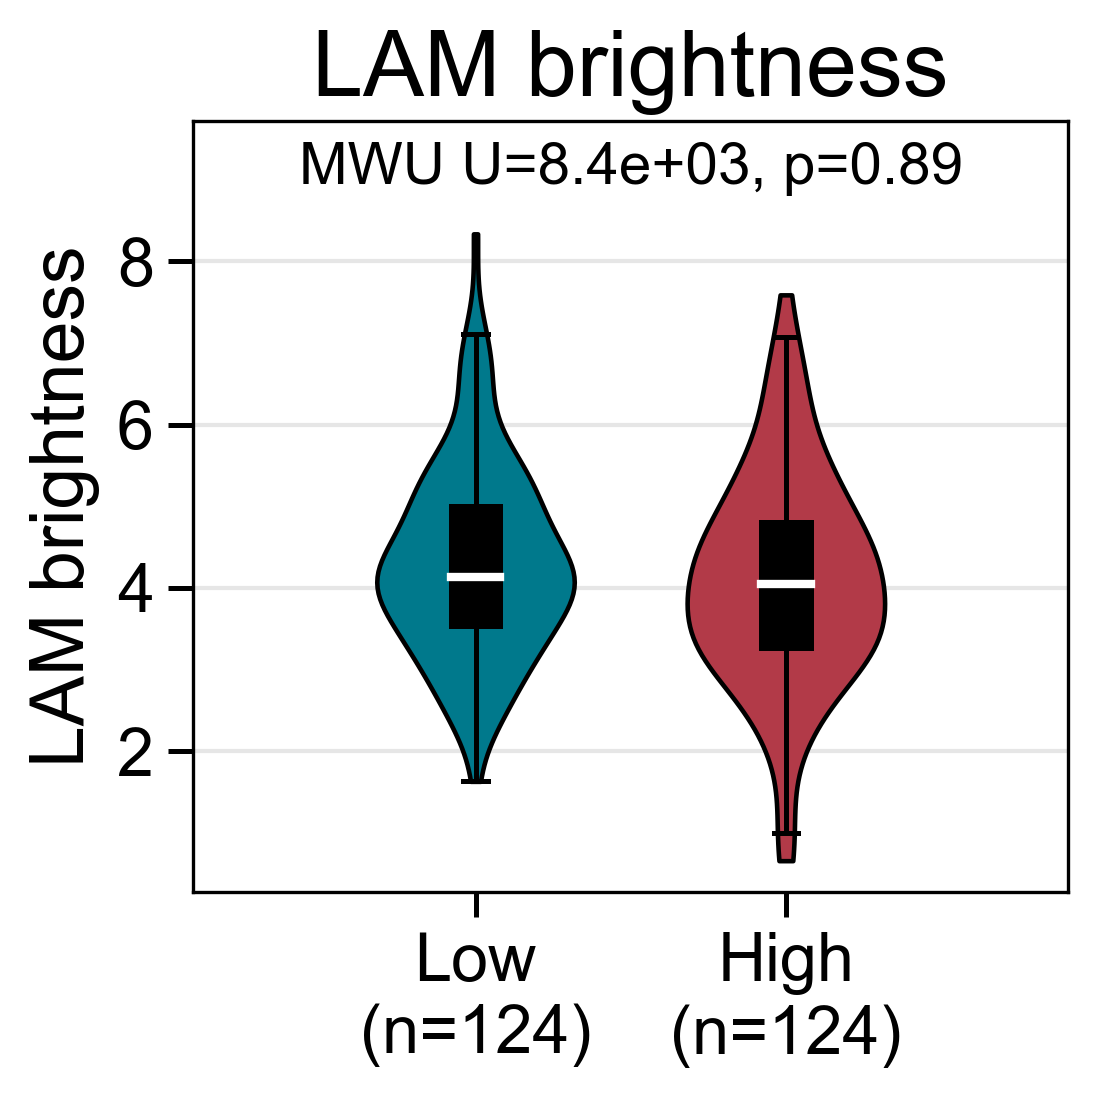

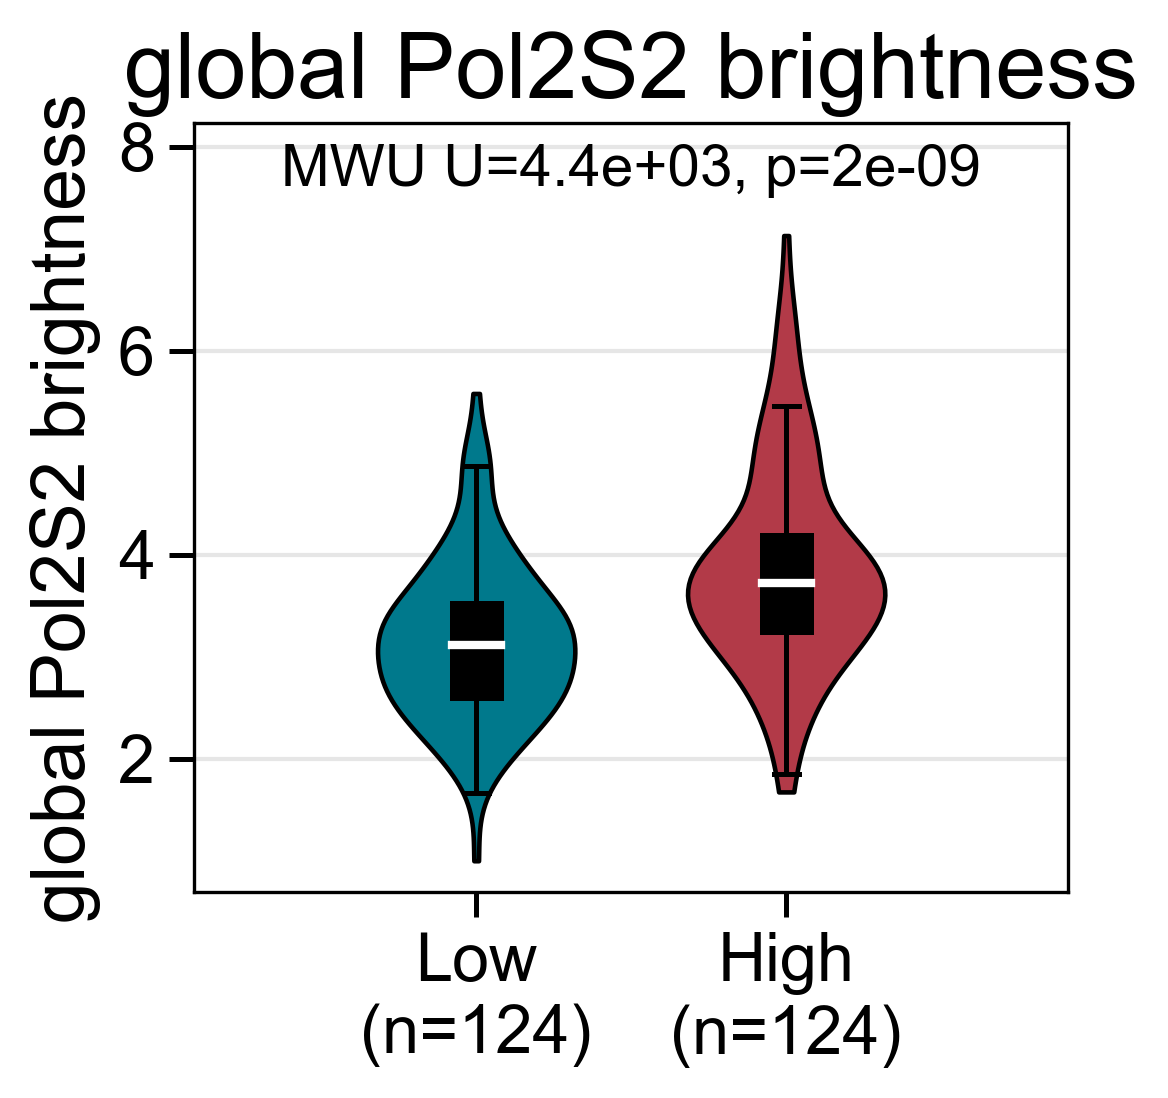

In [85]:
val_cols = [
    "rgs",
    "pct_genes_transcribed",
    "PolII_brightness_z",
    "H3K27Ac_brightness_z",
    'LAM_brightness_z', 
    'iA2_global_cell_mean',

    
]

titles = [
    "Rg",
    "bursting rate",
    "Pol2S2 brightness",
    "H3K27Ac brightness",
    "LAM brightness",
    "global Pol2S2 brightness",
]

for ax, val_col, title in zip(axes.ravel(), val_cols, titles):
    if title == 'Rg':
        ylabel = 'Rg (µm)'
    elif title =='bursting rate':
        ylabel = '% genes transcribed'
    else:
        ylabel = title
    #violin_two_groups_by_bool_mean(
    violin_two_groups_by_bool_mean_matplotlib(
    df=df_plot_violin,
    val_col=val_col,
    bool_col="is_low",  # your boolean column
    order = (True, False),
    group_labels={True: "Low", False: "High"},
    colors=("#00798C", "#B23A48"),
    title=title,
    y_label=ylabel,
    do_mannwhitney=True,
    rasterize_violins=False,
    # save_svg = None,
    fig_size=(4, 4),#(4.6, 4),
    mannwhitney_alternative="less", # "two-sided", "less"
    stats_fontsize=14,
    mean_dot_size = 50,
    x_gap=0.55,
    median_lw=2,
    # save_svg=f"C:/GBM39/manuscript_figures/invitro_fig2/plots/cell_level_low_high_features/low25_high25_violins_{title}.svg",
)

# copy number vs. exon counts

## import functions

In [114]:
import os, glob
import numpy as np
import pandas as pd

def build_introns_exons_matrix(intron_analysis_folder):
    all_cts = []  # rows = [ifovcell, gene, cyto_cts, nuc_cts]

    fls = glob.glob(os.path.join(intron_analysis_folder, '*iQ*'))
    for fl in fls:
        # parse file name
        base = os.path.basename(fl)
        ifovcell = int(base.split('--')[0][4:])  # e.g. Conv_zscan1__1234 → 1234

        # gene name from iQ part (customize depending on filename structure)
        iQ = base.split('--')[1]
        if iQ == 'iQ37': continue #### ##'PSPHP1_exons' doesnt exist
        gene_name = dic_iQ_gene[int(iQ[2:])]
        gene_label = f"{gene_name}__{iQ}"  # you can prepend "EGFR_introns-" if desired

        # load counts
        XiQ = np.load(fl)
        cyto_cts = len(XiQ)
        nuc_cts = np.count_nonzero(XiQ[:, -2] == 1)

        all_cts.append([ifovcell, gene_label, cyto_cts, nuc_cts])

    df_long = pd.DataFrame(all_cts, columns=["ifovcell", "gene", "cyto", "nuc"])

    # reshape into wide matrix: rows = ifovcell, columns = gene-cyto/nuc
    df_wide = (
        df_long
        .set_index(["ifovcell", "gene"])
        .stack()  # melt cyto/nuc
        .reset_index()
        .pivot(index="ifovcell", columns=["gene", "level_2"], values=0)
    )

    # flatten MultiIndex columns: "GENE-cyto", "GENE-nuc"
    df_wide.columns = [f"{gene}__{comp}" for gene, comp in df_wide.columns]

    df_wide = df_wide.fillna(0).astype(int)  # fill missing with 0
    return df_wide.reset_index()

In [68]:
def plot_ecEGFR_3points(
    df_plot,
    x_col='mean_P1F1F2_cts',
    y_col='EGFR',
    *,
    log2_scale=True,
    low_idx=None,
    high_idx=None,
    example_idx=None,
    s=14,
    alpha=0.35,
    point_color='#1f77b4',
    line_color='crimson',
    rasterize_points=True,
    title=None,
    font_family='Arial',
    ax=None,                 # NEW: draw on provided axis
    annotate_stats=True,     # NEW: toggle stats text
    stats_loc=(0.02, 0.98),  # NEW: where to put stats text
    title_fontsize=None,     # NEW: optional smaller titles for grids
    return_stats=False,      # NEW: optionally return r/p/n
):
    """
    Scatter of df_plot[x_col] vs df_plot[y_col].

    If log2_scale:
        - keep x>=0, y>=0
        - transform: lx = log2(x+1), ly = log2(y+1)
        - Pearson r on (lx, ly)
        - straight line fit in (lx, ly) space
        - axes are linear, in units of log2(value+1)
        - ticks only at integer values
    Else:
        - Pearson r on linear values
        - linear fit y = m*x + c
    """

    # Save and temporarily change font to Arial
    prev_font = mpl.rcParams.get('font.family', None)
    prev_svg  = mpl.rcParams.get('svg.fonttype', None)
    mpl.rcParams['font.family'] = font_family
    mpl.rcParams['svg.fonttype'] = 'none'  # keep text editable in SVG

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4.8))
        created_fig = True
    else:
        fig = ax.figure

    d = df_plot[[x_col, y_col]].copy()
    d = d.replace([np.inf, -np.inf], np.nan).dropna()

    if log2_scale:
        d = d[(d[x_col] >= 0) & (d[y_col] >= 0)]
        x_raw = d[x_col].to_numpy(float)
        y_raw = d[y_col].to_numpy(float)

        lx = np.log2(x_raw + 1.0)
        ly = np.log2(y_raw + 1.0)

        r, p = pearsonr(lx, ly) if len(lx) > 1 else (np.nan, np.nan)

        if len(lx) > 1:
            b, a = np.polyfit(lx, ly, 1)
            xx = np.linspace(lx.min(), lx.max(), 200)
            yy = a + b * xx
        else:
            xx = yy = None

        x_plot, y_plot = lx, ly

    else:
        x_plot = d[x_col].to_numpy(float)
        y_plot = d[y_col].to_numpy(float)

        r, p = pearsonr(x_plot, y_plot) if len(x_plot) > 1 else (np.nan, np.nan)

        if len(x_plot) > 1:
            m, c = np.polyfit(x_plot, y_plot, 1)
            xx = np.linspace(x_plot.min(), x_plot.max(), 200)
            yy = m * xx + c
        else:
            xx = yy = None

    sc = ax.scatter(
        x_plot, y_plot,
        s=s, alpha=alpha, color=point_color,
        edgecolors='none', zorder=2
    )
    if rasterize_points:
        sc.set_rasterized(True)

    if xx is not None:
        ax.plot(xx, yy, color=line_color, lw=2.2, zorder=3)

    # highlight specific points by DataFrame index
    def highlight(idx, color):
        if idx is None:
            return
        if idx not in d.index:
            return
        x0 = d.loc[idx, x_col]
        y0 = d.loc[idx, y_col]
        if log2_scale:
            x0 = np.log2(x0 + 1.0)
            y0 = np.log2(y0 + 1.0)
        ax.scatter(
            [x0], [y0],
            s=70, color=color, edgecolor='black',
            linewidth=1.0, zorder=4
        )

    highlight(low_idx, 'red')
    highlight(high_idx, 'gold')
    highlight(example_idx, 'green')

    if log2_scale:
        ax.set_xlabel('ecDNA copy number (log2)')
        ax.set_ylabel(f'gene expression (log2)')
        ttl = title or f'{y_col} vs {x_col} (log2+1–log2+1)'

        def set_int_ticks(vals, axis='x'):
            if len(vals) == 0:
                return
            vmin, vmax = vals.min(), vals.max()
            lo = np.floor(vmin)
            hi = np.ceil(vmax)
            ticks = np.arange(lo, hi + 1)
            if axis == 'x':
                ax.set_xticks(ticks)
                ax.set_xticklabels([f'{int(t)}' for t in ticks])
            else:
                ax.set_yticks(ticks)
                ax.set_yticklabels([f'{int(t)}' for t in ticks])

        set_int_ticks(x_plot, axis='x')
        set_int_ticks(y_plot, axis='y')

    else:
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
        ttl = title or f'{y_col} vs {x_col}'

    ax.set_title(ttl, fontsize=title_fontsize)
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(0, ymax)

    if annotate_stats:
        txt = f"Pearson r = {r:.2f}\np = {p:.2e}"
        ax.text(
            stats_loc[0], stats_loc[1],
            txt,
            transform=ax.transAxes,
            ha='left', va='top'
        )

    if created_fig:
        plt.tight_layout()

    # restore previous font / svg settings
    if prev_font is not None:
        mpl.rcParams['font.family'] = prev_font
    if prev_svg is not None:
        mpl.rcParams['svg.fonttype'] = prev_svg

    if return_stats:
        return {"r": r, "p": p, "n": int(len(x_plot)), "x_col": x_col, "y_col": y_col}
    return None

In [69]:
def plot_ecEGFR_3points_grid(
    df_plot,
    y_cols,
    *,
    x_col='ecDNA_mean_6_regions',
    ncols=4,
    figsize=None,
    log2_scale=True,
    low_idx=None,
    high_idx=None,
    example_idx=None,
    s=14,
    alpha=0.35,
    point_color='#1f77b4',
    line_color='crimson',
    rasterize_points=True,
    font_family='Arial',
    title_prefix=None,
    sharex=True,          # <- default True now
    sharey=True,          # <- default True now
    tight_layout=True,
    save_path=None,
    dpi=600,
    # NEW:
    xlabel=None,
    ylabel=None,
    label_fontsize=14,
):
    """
    Make a grid of subplots; one panel per y_col.
    Shares x/y across panels and draws x/y labels only once.
    """
    y_cols = list(y_cols)
    n = len(y_cols)
    nrows = int(np.ceil(n / ncols))

    if figsize is None:
        figsize = (3.8 * ncols, 3.2 * nrows)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=figsize,
        sharex=sharex, sharey=sharey
    )
    axes = np.array(axes).reshape(-1)

    for i, y_col in enumerate(y_cols):
        ax = axes[i]
        ttl = y_col.replace("_exons_cyto","") if title_prefix is None else f"{title_prefix}{y_col}"

        plot_ecEGFR_3points(
            df_plot,
            x_col=x_col,
            y_col=y_col,
            log2_scale=log2_scale,
            low_idx=low_idx,
            high_idx=high_idx,
            example_idx=example_idx,
            s=s,
            alpha=alpha,
            point_color=point_color,
            line_color=line_color,
            rasterize_points=rasterize_points,
            title=ttl,
            font_family=font_family,
            ax=ax,
            title_fontsize=20,
            # IMPORTANT: don't let the per-panel function draw labels
        )
        ax.set_xlabel("")
        ax.set_ylabel("")

        # Optional: only show outer tick labels (cleaner grid)
        ax.label_outer()

    # turn off any unused axes
    for j in range(n, len(axes)):
        axes[j].axis("off")

    # One set of axis labels for the whole figure
    if xlabel is None:
        xlabel = "ecDNA copy number (log2)" if log2_scale else x_col
    if ylabel is None:
        ylabel = "gene expression (log2)" if log2_scale else "gene expression"

    fig.supxlabel(xlabel, fontsize=label_fontsize)
    fig.supylabel(ylabel, fontsize=label_fontsize)

    if tight_layout:
        # leave room for sup labels
        fig.tight_layout(rect=(0.04, 0.04, 1, 0.98))

    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

    return fig, axes[:n]


## get exon counts

In [116]:
from ecDNATracer_HelperFunctions import *

In [129]:
dic_iQ_gene = {19: 'EGFR-AS1_exons',
 20: 'EGFR-AS1_introns',
 21: 'EGFR_exons',
 22: 'EGFR_introns',
 23: 'FKBP9P1_exons',
 24: 'FKBP9P1_introns',
 25: 'LANCL2_exons',
 26: 'LANCL2_introns',
 29: 'MRPS17_exons',
 30: 'MRPS17_introns',
 31: 'NIPSNAP2_exons',
 32: 'NIPSNAP2_introns',
 38: 'PSPH_exons',
 39: 'PSPH_introns',
 40: 'SEPTIN14_exons',
 41: 'SEPTIN14_introns',
 47: 'ZNF713_exons',
 48: 'ZNF713_introns'}

In [130]:
dic_th = dict(zip(dic_iQ_gene.keys(), [1.5] * len(dic_iQ_gene.keys())))
for iQ in [24,30,39,41,48]:
    dic_th[iQ] = 1

In [118]:
## run this for FOV 20-150
intron_analysis_folder = r'D:\GBM39\ecDNATracer\intronQ_analysis__invitro_03012025\anchor_points-iQ'

for iQ in tqdm(list(dic_iQ_gene.keys())):
    for ifov in range(20,151):
        fov = f'Conv_zscan1__{str(int(ifov)).zfill(3)}'
        XF = np.load(os.path.join(r'D:\GBM39\ecDNATracer\fulldata__Q__invitro_03012025', f'{fov}_colorflip_chromabb--XF.npz'))['XF']

        ## get the bright spots
        ## EGFR intron
        X_EGFR = get_bright_points_per_R(XF, iR = iQ, 
                                medh = medh_RNA, uRs = uRs_RNA,
                                    th_hlow = dic_th[iQ], ## std above the min
                                    th_dd = 3, H_col = -5)
        for ucell in np.unique(XF[:, -1]):
            X_EGFR_cell = X_EGFR[X_EGFR[:, -1] == ucell]
            ## save this!
            ifovcell = int(10**5 * ifov + ucell)
            save_fl = os.path.join(intron_analysis_folder, f'cell{ifovcell}--iQ{iQ}--th_h{th_hlow}--XFb.npy')
            np.save(save_fl, X_EGFR_cell)

In [121]:
df_introns_exons = build_introns_exons_matrix(intron_analysis_folder)

## plot exons

In [123]:
df_cts = pd.read_csv(r'C:/GBM39/invirto_030125/112325__df_mean6DNA-intron-exon_cts__invitro_030125.csv', index_col = 0)
df_cts['cell_id'] = df_cts['fov_ifovcell'].apply(lambda x: int(x.split('_')[-1]))
df_cts['iset'] = df_cts['fov_ifovcell'].apply(lambda x: int(x.split('__')[0].split('Conv_zscan')[-1]))

In [70]:
# df_introns_exons = pd.read_csv(r'C:/GBM39/invirto_030125/091625_smFISHRNA_genesOnChr7_intron_exons_FOV20-150.csv', index_col = 0)

In [133]:
exon_cyto_columns = [col for col in df_introns_exons.columns if ('exon' in col) & ('cyto' in col)]
# exon_cyto_columns

In [125]:
df_exons = df_introns_exons[exon_cyto_columns].rename(
    columns={col: f'{col.split("exons")[0]}exons_cyto' for col in exon_cyto_columns}
)
df_exons['cell_id'] = df_introns_exons['ifovcell']

In [126]:
exon_genes = [col.split('_')[0] for col in exon_cyto_columns]

In [127]:
df_plot = pd.merge(df_cts[df_cts['iset'] == 1][['cell_id','fov_ifovcell', 'ecDNA_mean_6_regions']], 
                   df_exons,
                  on = 'cell_id',
                  how = 'inner')
df_plot.shape

(3322, 13)

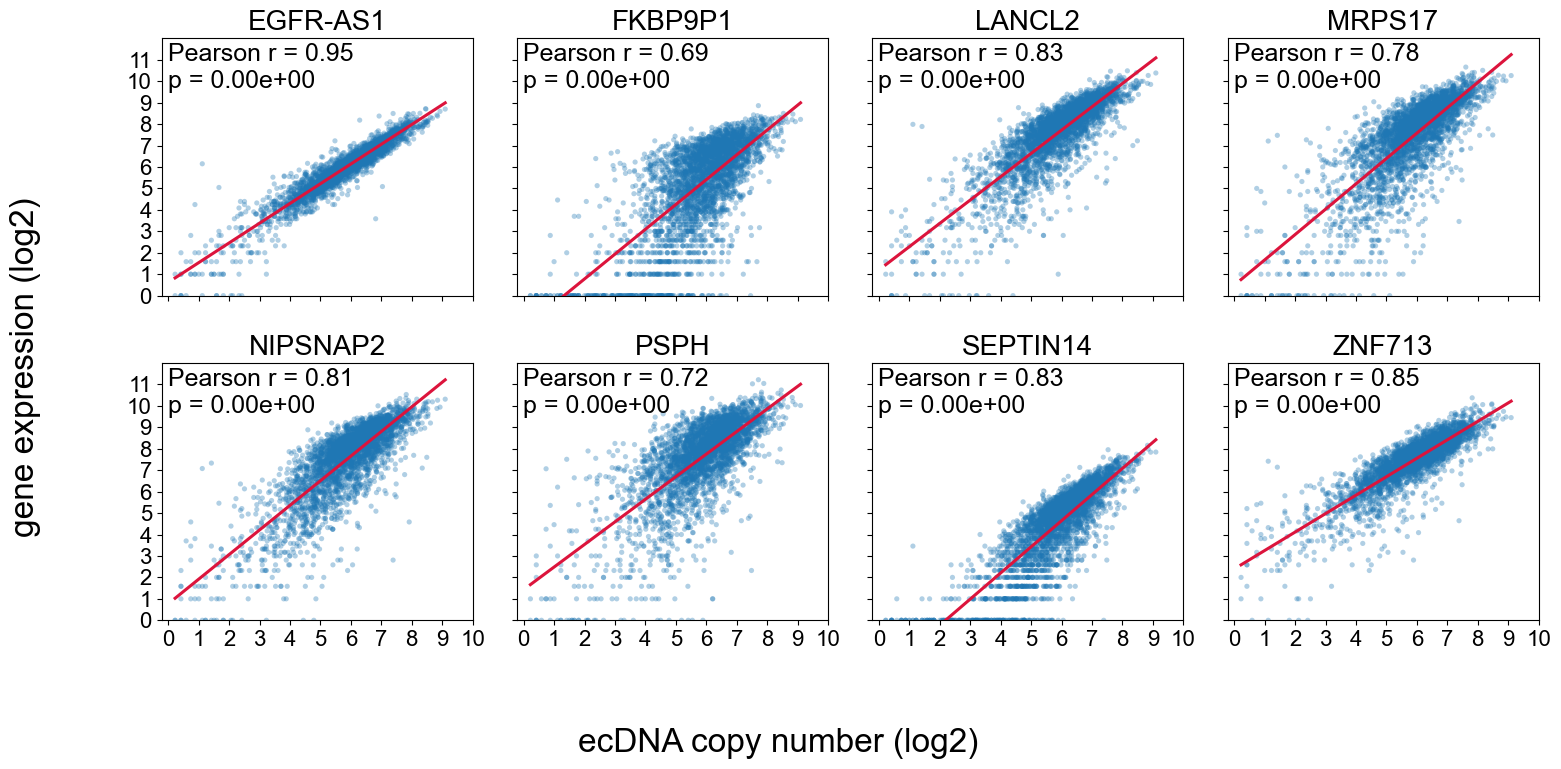

In [128]:
y_cols = [f"{g}_exons_cyto" for g in exon_genes if ~np.isin(g, ['EGFR', 'VOPP1'])]

fig, axes = plot_ecEGFR_3points_grid(
    df_plot,
    figsize=(16,8),
    y_cols=y_cols,
    x_col="ecDNA_mean_6_regions",
    ncols=4,  # choose grid width
    log2_scale=True,
    rasterize_points=True,
    title_prefix=None,
    label_fontsize = 24,
    # save_path='C:/GBM39/manuscript_figures/extended_invitro_fig2/plots/ecEGFR_gene_grid/ecEGFR_8genes_2x4_log2copy_log2-exon-cyto.svg'
)
plt.show()


## plot EGFR with example points annotated

In [106]:
## low cell
low_cell_fullid = 'Conv_zscan1__070_7000027'
df_plot[df_plot['fov_ifovcell'] == low_cell_fullid] 

,cell_id,fov_ifovcell,ecDNA_mean_6_regions,EGFR-AS1_exons_cyto,EGFR_exons_cyto,FKBP9P1_exons_cyto,LANCL2_exons_cyto,MRPS17_exons_cyto,NIPSNAP2_exons_cyto,PSPH_exons_cyto,SEPTIN14_exons_cyto,VOPP1_exons_cyto,ZNF713_exons_cyto
1177,7000027,Conv_zscan1__070_7000027,8.833333,7,15,0,13,0,8,0,0,7,12


In [107]:
## low cell
high_cell_fullid = 'Conv_zscan1__058_5800014'
df_plot[df_plot['fov_ifovcell'] == high_cell_fullid]

,cell_id,fov_ifovcell,ecDNA_mean_6_regions,EGFR-AS1_exons_cyto,EGFR_exons_cyto,FKBP9P1_exons_cyto,LANCL2_exons_cyto,MRPS17_exons_cyto,NIPSNAP2_exons_cyto,PSPH_exons_cyto,SEPTIN14_exons_cyto,VOPP1_exons_cyto,ZNF713_exons_cyto
854,5800014,Conv_zscan1__058_5800014,203.166667,204,610,212,613,628,698,647,101,994,534


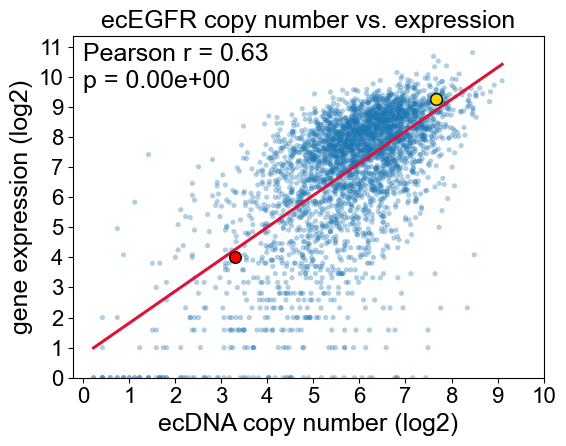

In [108]:
plot_ecEGFR_3points(df_plot, x_col='ecDNA_mean_6_regions',y_col='EGFR_exons_cyto',
                    low_idx=1177, high_idx=854, example_idx = None,
                    log2_scale=True,rasterize_points=True,
            # save_path=None, 
            title = 'ecEGFR copy number vs. expression')